In [1]:
import sys
print(sys.executable)

C:\Users\USUARIO\AppData\Local\pypoetry\Cache\virtualenvs\desarrollo-social-y-economico-SY8rErmS-py3.12\Scripts\python.exe


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_parquet(
    r"C:\Users\USUARIO\Desktop\2026\CONSULTORIA\desarrollo_social_y_economico-Cruce-Dane-Secop\desarrollo_social_y_economico-Cruce-Dane-Secop\datos\cruce_secop_dane_sprint2.parquet"
)

df.head()

,código_departamento,nombre_departamento,código_municipio,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_miseria,necesidades_basicas_insatisfechas_por_categorias_%_componente_vivienda,necesidades_basicas_insatisfechas_por_categorias_%_componente_servicios,necesidades_basicas_insatisfechas_por_categorias_%_componente_hacinamiento,necesidades_basicas_insatisfechas_por_categorias_%_componente_inasistencia,...,etnia_afro_count,etnia_ninguno_count,etnia_sin_info_count,etnia_indigena_pct,etnia_rrom_pct,etnia_raizal_pct,etnia_palenquero_pct,etnia_afro_pct,etnia_ninguno_pct,etnia_sin_info_pct
0,05,ANTIOQUIA,001,MEDELLÍN,5.230398664972173,0.41728094869016497,0.28464264571461745,0.1887023524441256,1.555427767002387,1.6148819328409472,...,59064.0,2279605.0,31165.0,0.087298,0.002023,0.013236,0.002656,2.489704,96.091395,1.313687
1,05,ANTIOQUIA,002,ABEJORRAL,13.958914243441644,1.3657315199453708,0.37557616798497695,0.4950776759801969,2.663176463893473,1.2405394639503784,...,62.0,17428.0,107.0,0.011364,0.000000,0.000000,0.000000,0.352293,99.028354,0.607989
2,05,ANTIOQUIA,004,ABRIAQUÍ,11.630079402148528,1.2143858010275572,1.7281644091546007,1.5880429705744978,2.335357309668379,0.6071929005137786,...,43.0,2091.0,24.0,0.000000,0.046318,0.000000,0.000000,1.991663,96.850394,1.111626
3,05,ANTIOQUIA,021,ALEJANDRÍA,12.676424464192367,0.8886565603763722,0.705697856769472,0.07841087297438579,1.9864087820177732,0.8886565603763722,...,12.0,3797.0,30.0,0.000000,0.000000,0.000000,0.000000,0.312581,98.905965,0.781454
4,05,ANTIOQUIA,030,AMAGÁ,9.663881290515981,0.9367857009030615,0.5283471353093266,0.2772885674673062,2.3681942518829393,1.907295687038633,...,125.0,26608.0,74.0,0.033556,0.007457,0.000000,0.011185,0.466053,99.205846,0.275903


2. Inspección inicial

In [18]:
# ============================================================================
# 2. Inspección inicial mejorada
# ============================================================================
print("=" * 60)
print("INSPECCIÓN INICIAL DE LOS DATOS")
print("=" * 60)

print(f"\n📊 Dimensiones: {df.shape[0]} municipios × {df.shape[1]} variables")

print(f"\n📋 Columnas disponibles ({len(df.columns)}):")
for i, col in enumerate(df.columns.tolist()):
    print(f"  {i+1:3d}. {col}")

print("\n🔍 Primeras 3 filas:")
display(df.head(3))

print("\n📈 Información del DataFrame:")
df.info()

print("\n🚨 Valores nulos por columna (top 10):")
nulos = df.isnull().sum().sort_values(ascending=False)
for col, val in nulos.head(10).items():
    pct = (val / len(df)) * 100
    print(f"  {col}: {val} ({pct:.1f}%)")

INSPECCIÓN INICIAL DE LOS DATOS

📊 Dimensiones: 1124 municipios × 44 variables

📋 Columnas disponibles (44):
    1. código_departamento
    2. nombre_departamento
    3. código_municipio
    4. nombre_municipio
    5. necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)
    6. necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_miseria
    7. necesidades_basicas_insatisfechas_por_categorias_%_componente_vivienda
    8. necesidades_basicas_insatisfechas_por_categorias_%_componente_servicios
    9. necesidades_basicas_insatisfechas_por_categorias_%_componente_hacinamiento
   10. necesidades_basicas_insatisfechas_por_categorias_%_componente_inasistencia
   11. necesidades_basicas_insatisfechas_por_categorias_%_componente_dependencia_económica
   12. necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%).1
   13. necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_miseria.1
   14. necesidades_basicas_in

,código_departamento,nombre_departamento,código_municipio,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_miseria,necesidades_basicas_insatisfechas_por_categorias_%_componente_vivienda,necesidades_basicas_insatisfechas_por_categorias_%_componente_servicios,necesidades_basicas_insatisfechas_por_categorias_%_componente_hacinamiento,necesidades_basicas_insatisfechas_por_categorias_%_componente_inasistencia,...,etnia_afro_count,etnia_ninguno_count,etnia_sin_info_count,etnia_indigena_pct,etnia_rrom_pct,etnia_raizal_pct,etnia_palenquero_pct,etnia_afro_pct,etnia_ninguno_pct,etnia_sin_info_pct
0,05,ANTIOQUIA,001,MEDELLÍN,5.230399,0.41728094869016497,0.28464264571461745,0.1887023524441256,1.555427767002387,1.6148819328409472,...,59064.0,2279605.0,31165.0,0.087298,0.002023,0.013236,0.002656,2.489704,96.091395,1.313687
1,05,ANTIOQUIA,002,ABEJORRAL,13.958914,1.3657315199453708,0.37557616798497695,0.4950776759801969,2.663176463893473,1.2405394639503784,...,62.0,17428.0,107.0,0.011364,0.000000,0.000000,0.000000,0.352293,99.028354,0.607989
2,05,ANTIOQUIA,004,ABRIAQUÍ,11.630079,1.2143858010275572,1.7281644091546007,1.5880429705744978,2.335357309668379,0.6071929005137786,...,43.0,2091.0,24.0,0.000000,0.046318,0.000000,0.000000,1.991663,96.850394,1.111626



📈 Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 44 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   código_departamento                                                                    1124 non-null   object 
 1   nombre_departamento                                                                    1123 non-null   object 
 2   código_municipio                                                                       1123 non-null   object 
 3   nombre_municipio                                                                       1123 non-null   object 
 4   necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)         1123 non-null   float64
 5   necesidades_basicas_insatisfechas_por_categori

3. Preparación de variables

Aquí conviertes el NBI a numérico y dejas listas las variables clave.

In [14]:
# ============================================================================
# 3. Preparación de variables con validación
# ============================================================================
print("=" * 60)
print("PREPARACIÓN DE VARIABLES")
print("=" * 60)

col_nbi = "necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)"

# Convertir a numérico con manejo de errores
df[col_nbi] = pd.to_numeric(df[col_nbi], errors="coerce")
df["monto_total_contratos"] = pd.to_numeric(df["monto_total_contratos"], errors="coerce")
df["num_contratos"] = pd.to_numeric(df["num_contratos"], errors="coerce")
df["ipm_total"] = pd.to_numeric(df["ipm_total"], errors="coerce")

# Estadísticas descriptivas
print("\n📊 Estadísticas de variables clave:")
display(df[[col_nbi, "monto_total_contratos", "num_contratos", "ipm_total"]].describe())

# Identificar valores extremos
print("\n⚠️ Valores extremos (percentil 99):")
for col in ["monto_total_contratos", "num_contratos"]:
    p99 = df[col].quantile(0.99)
    print(f"  {col}: {p99:,.0f}")

PREPARACIÓN DE VARIABLES

📊 Estadísticas de variables clave:


,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos,num_contratos,ipm_total
count,1123.000000,1.124000e+03,1124.000000,1122.000000
mean,22.920305,1.973298e+07,5.652135,41.792424
std,17.749594,5.694623e+08,81.145478,17.345540
min,1.591327,0.000000e+00,0.000000,4.500000
25%,10.968778,0.000000e+00,0.000000,30.225000
50%,16.748548,0.000000e+00,0.000000,40.800000
75%,28.664713,0.000000e+00,0.000000,52.675000
max,95.963756,1.899977e+10,1998.000000,98.500000



⚠️ Valores extremos (percentil 99):
  monto_total_contratos: 0
  num_contratos: 49


4. Distribución de la inversión



DISTRIBUCIÓN DE LA INVERSIÓN MUNICIPAL


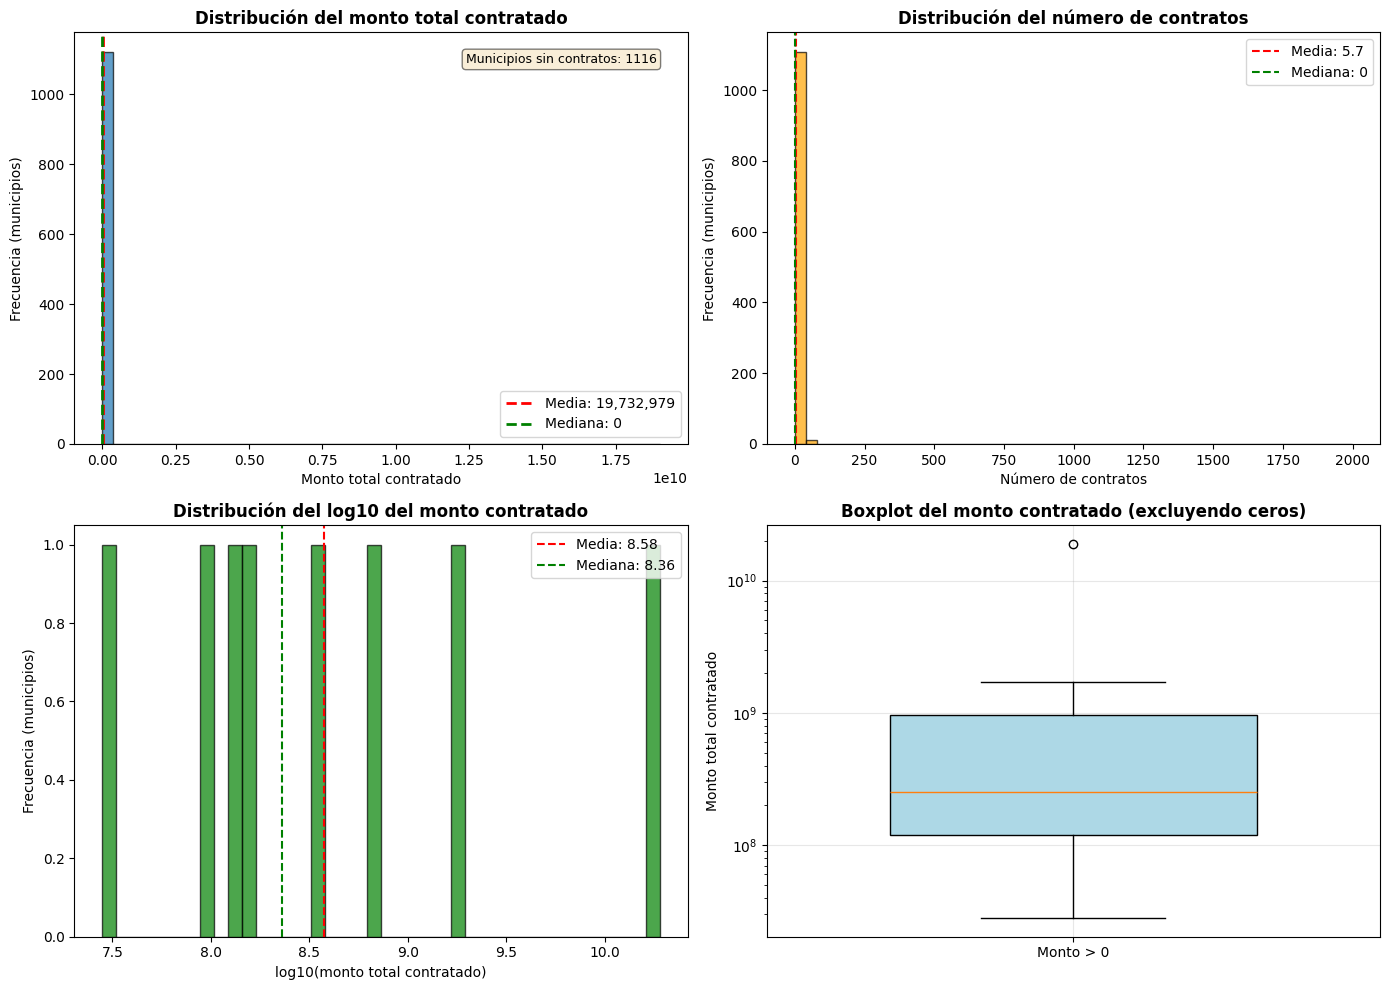


📈 Resumen de distribución de contratación:
  • Municipios sin contratos: 1,116 (99.3%)
  • Municipios con contratos: 8
  • Monto total contratado: $22,179,868,125
  • Promedio por municipio (incluye ceros): $19,732,979
  • Promedio por municipio (solo con contratos): $2,772,483,516


In [15]:
# ============================================================================
# 4. Distribución de la inversión (mejorado)
# ============================================================================
print("=" * 60)
print("DISTRIBUCIÓN DE LA INVERSIÓN MUNICIPAL")
print("=" * 60)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Histograma de monto total
ax1 = axes[0, 0]
data_monto = df["monto_total_contratos"].fillna(0)
ax1.hist(data_monto, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(data_monto.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data_monto.mean():,.0f}')
ax1.axvline(data_monto.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {data_monto.median():,.0f}')
ax1.set_title("Distribución del monto total contratado", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monto total contratado")
ax1.set_ylabel("Frecuencia (municipios)")
ax1.legend()
ax1.text(0.95, 0.95, f"Municipios sin contratos: {(data_monto == 0).sum()}", 
         transform=ax1.transAxes, ha='right', va='top', fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4.2 Histograma del número de contratos
ax2 = axes[0, 1]
data_contratos = df["num_contratos"].fillna(0)
ax2.hist(data_contratos, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax2.axvline(data_contratos.mean(), color='red', linestyle='--', label=f'Media: {data_contratos.mean():.1f}')
ax2.axvline(data_contratos.median(), color='green', linestyle='--', label=f'Mediana: {data_contratos.median():.0f}')
ax2.set_title("Distribución del número de contratos", fontsize=12, fontweight='bold')
ax2.set_xlabel("Número de contratos")
ax2.set_ylabel("Frecuencia (municipios)")
ax2.legend()

# 4.3 Log del monto (excluyendo ceros)
ax3 = axes[1, 0]
df_monto_pos = df[df["monto_total_contratos"] > 0].copy()
df_monto_pos["log_monto"] = np.log10(df_monto_pos["monto_total_contratos"])
ax3.hist(df_monto_pos["log_monto"], bins=40, edgecolor='black', alpha=0.7, color='green')
ax3.axvline(df_monto_pos["log_monto"].mean(), color='red', linestyle='--', 
            label=f'Media: {df_monto_pos["log_monto"].mean():.2f}')
ax3.axvline(df_monto_pos["log_monto"].median(), color='green', linestyle='--', 
            label=f'Mediana: {df_monto_pos["log_monto"].median():.2f}')
ax3.set_title("Distribución del log10 del monto contratado", fontsize=12, fontweight='bold')
ax3.set_xlabel("log10(monto total contratado)")
ax3.set_ylabel("Frecuencia (municipios)")
ax3.legend()

# 4.4 Boxplot comparativo (con y sin log)
ax4 = axes[1, 1]
monto_no_cero = df[df["monto_total_contratos"] > 0]["monto_total_contratos"]
bp = ax4.boxplot([monto_no_cero], positions=[1], widths=0.6, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax4.set_xticks([1])
ax4.set_xticklabels(['Monto > 0'])
ax4.set_title("Boxplot del monto contratado (excluyendo ceros)", fontsize=12, fontweight='bold')
ax4.set_ylabel("Monto total contratado")
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas resumen
print("\n📈 Resumen de distribución de contratación:")
print(f"  • Municipios sin contratos: {(data_monto == 0).sum():,} ({((data_monto == 0).sum()/len(df))*100:.1f}%)")
print(f"  • Municipios con contratos: {(data_monto > 0).sum():,}")
print(f"  • Monto total contratado: ${data_monto.sum():,.0f}")
print(f"  • Promedio por municipio (incluye ceros): ${data_monto.mean():,.0f}")
print(f"  • Promedio por municipio (solo con contratos): ${monto_no_cero.mean():,.0f}")

DISTRIBUCIÓN DE LA VULNERABILIDAD MUNICIPAL


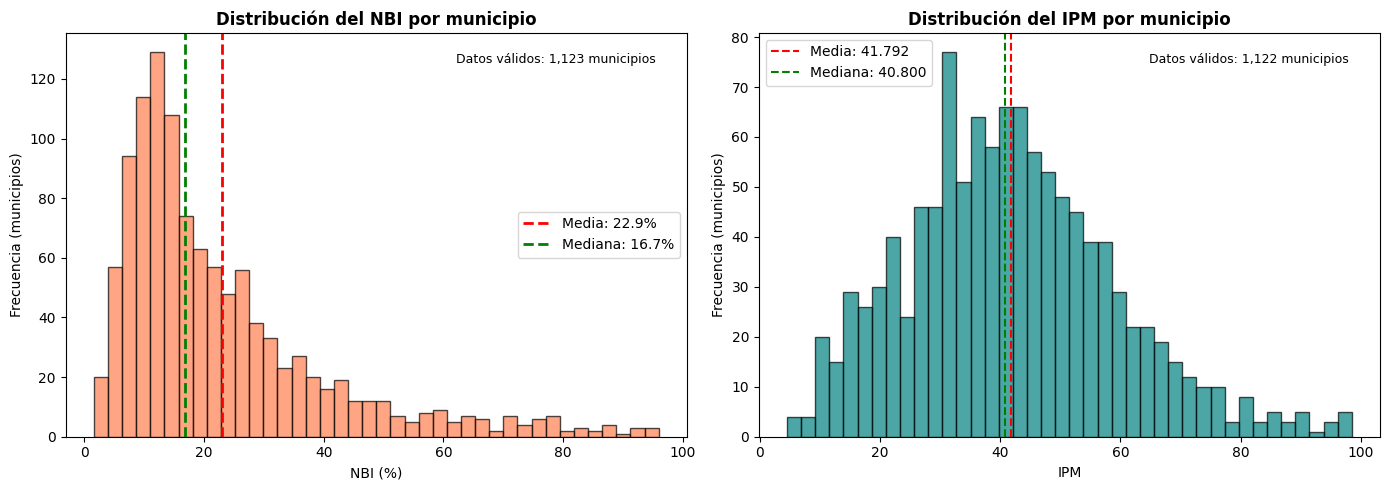

In [17]:
# ============================================================================
# 5. Distribución de la vulnerabilidad (mejorado)
# ============================================================================
print("=" * 60)
print("DISTRIBUCIÓN DE LA VULNERABILIDAD MUNICIPAL")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5.1 Histograma de NBI
ax1 = axes[0]
nbi_data = df[col_nbi].dropna()
ax1.hist(nbi_data, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax1.axvline(nbi_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media: {nbi_data.mean():.1f}%')
ax1.axvline(nbi_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Mediana: {nbi_data.median():.1f}%')
ax1.set_title("Distribución del NBI por municipio", fontsize=12, fontweight='bold')
ax1.set_xlabel("NBI (%)")
ax1.set_ylabel("Frecuencia (municipios)")
ax1.legend()
ax1.text(0.95, 0.95, f"Datos válidos: {len(nbi_data):,} municipios", 
         transform=ax1.transAxes, ha='right', va='top', fontsize=9)

# 5.2 Histograma de IPM
ax2 = axes[1]
ipm_data = df["ipm_total"].dropna()
ax2.hist(ipm_data, bins=40, edgecolor='black', alpha=0.7, color='teal')
ax2.axvline(ipm_data.mean(), color='red', linestyle='--', 
            label=f'Media: {ipm_data.mean():.3f}')
ax2.axvline(ipm_data.median(), color='green', linestyle='--', 
            label=f'Mediana: {ipm_data.median():.3f}')
ax2.set_title("Distribución del IPM por municipio", fontsize=12, fontweight='bold')
ax2.set_xlabel("IPM")
ax2.set_ylabel("Frecuencia (municipios)")
ax2.legend()
ax2.text(0.95, 0.95, f"Datos válidos: {len(ipm_data):,} municipios", 
         transform=ax2.transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

CONCENTRACIÓN DE LA INVERSIÓN

💰 Concentración del monto contratado:
  • Top 10 municipios concentran: 100.0% del total
  • Top 20 municipios concentran: 100.0% del total


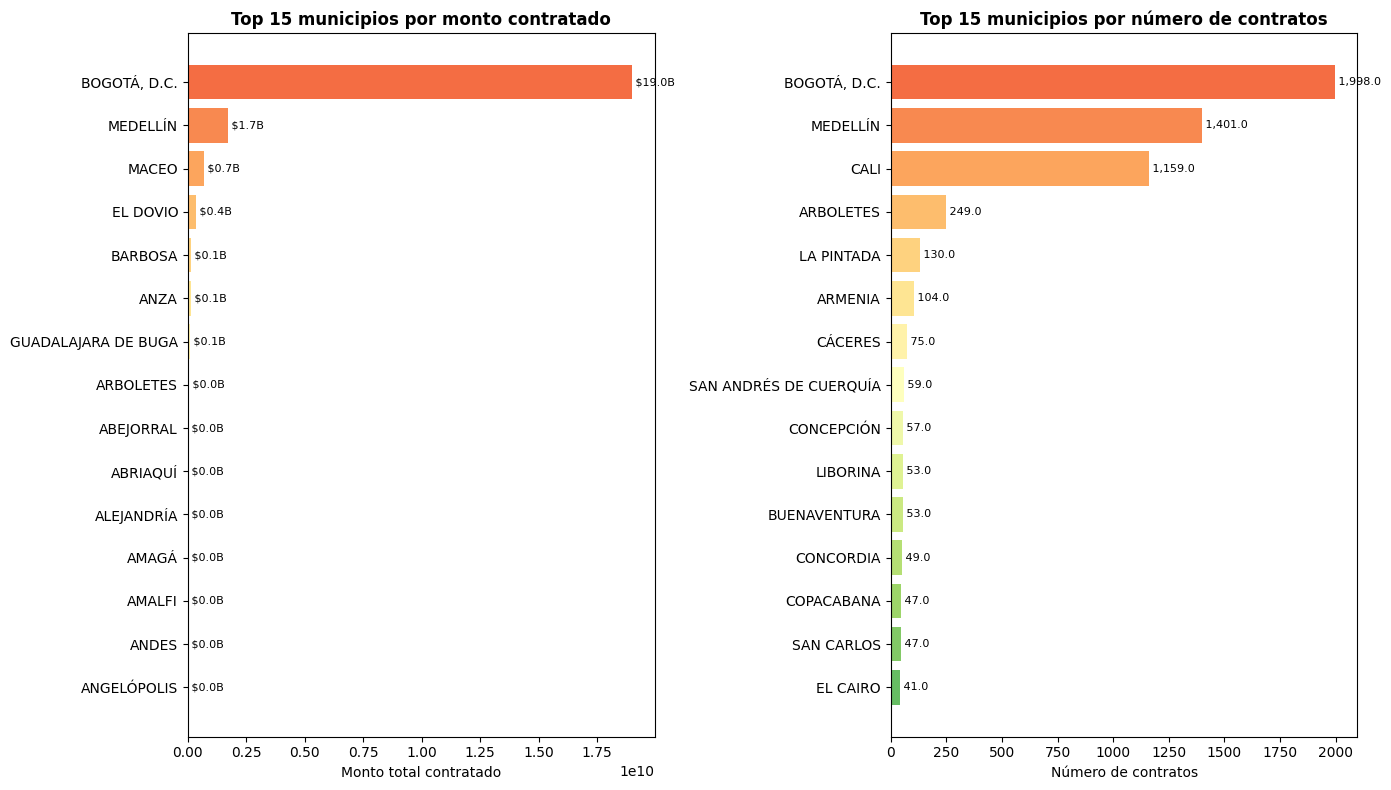


📋 Top 10 municipios por monto contratado:


,nombre_departamento,nombre_municipio,monto_total_contratos,num_contratos
148,"BOGOTÁ, D.C.","BOGOTÁ, D.C.",1.899977e+10,1998.0
0,ANTIOQUIA,MEDELLÍN,1.714617e+09,1401.0
67,ANTIOQUIA,MACEO,7.115000e+08,6.0
1022,VALLE DEL CAUCA,EL DOVIO,3.558835e+08,32.0
16,ANTIOQUIA,BARBOSA,1.500000e+08,24.0
11,ANTIOQUIA,ANZA,1.300000e+08,30.0
1012,VALLE DEL CAUCA,GUADALAJARA DE BUGA,9.000000e+07,16.0
13,ANTIOQUIA,ARBOLETES,2.810000e+07,249.0
1,ANTIOQUIA,ABEJORRAL,0.000000e+00,3.0
2,ANTIOQUIA,ABRIAQUÍ,0.000000e+00,0.0


In [19]:
# ============================================================================
# 6. Municipios que concentran más inversión (mejorado)
# ============================================================================
print("=" * 60)
print("CONCENTRACIÓN DE LA INVERSIÓN")
print("=" * 60)

# Calcular concentración
monto_total = df["monto_total_contratos"].sum()
top10_monto = df.nlargest(10, "monto_total_contratos")
top20_monto = df.nlargest(20, "monto_total_contratos")

print(f"\n💰 Concentración del monto contratado:")
print(f"  • Top 10 municipios concentran: {top10_monto['monto_total_contratos'].sum()/monto_total*100:.1f}% del total")
print(f"  • Top 20 municipios concentran: {top20_monto['monto_total_contratos'].sum()/monto_total*100:.1f}% del total")

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 6.1 Top 15 por monto contratado
ax1 = axes[0]
top_monto = df.nlargest(15, "monto_total_contratos")
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_monto)))
bars1 = ax1.barh(range(len(top_monto)), top_monto["monto_total_contratos"], color=colors)
ax1.set_yticks(range(len(top_monto)))
ax1.set_yticklabels(top_monto["nombre_municipio"])
ax1.invert_yaxis()
ax1.set_title("Top 15 municipios por monto contratado", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monto total contratado")
# Agregar etiquetas de valor
for i, (bar, val) in enumerate(zip(bars1, top_monto["monto_total_contratos"])):
    ax1.text(val, bar.get_y() + bar.get_height()/2, 
             f' ${val/1e9:.1f}B', ha='left', va='center', fontsize=8)

# 6.2 Top 15 por número de contratos
ax2 = axes[1]
top_contratos = df.nlargest(15, "num_contratos")
bars2 = ax2.barh(range(len(top_contratos)), top_contratos["num_contratos"], color=colors)
ax2.set_yticks(range(len(top_contratos)))
ax2.set_yticklabels(top_contratos["nombre_municipio"])
ax2.invert_yaxis()
ax2.set_title("Top 15 municipios por número de contratos", fontsize=12, fontweight='bold')
ax2.set_xlabel("Número de contratos")
for i, (bar, val) in enumerate(zip(bars2, top_contratos["num_contratos"])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, 
             f' {val:,}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Mostrar tabla detallada
print("\n📋 Top 10 municipios por monto contratado:")
display(top10_monto[["nombre_departamento", "nombre_municipio", "monto_total_contratos", "num_contratos"]])

MUNICIPIOS CON MAYOR VULNERABILIDAD


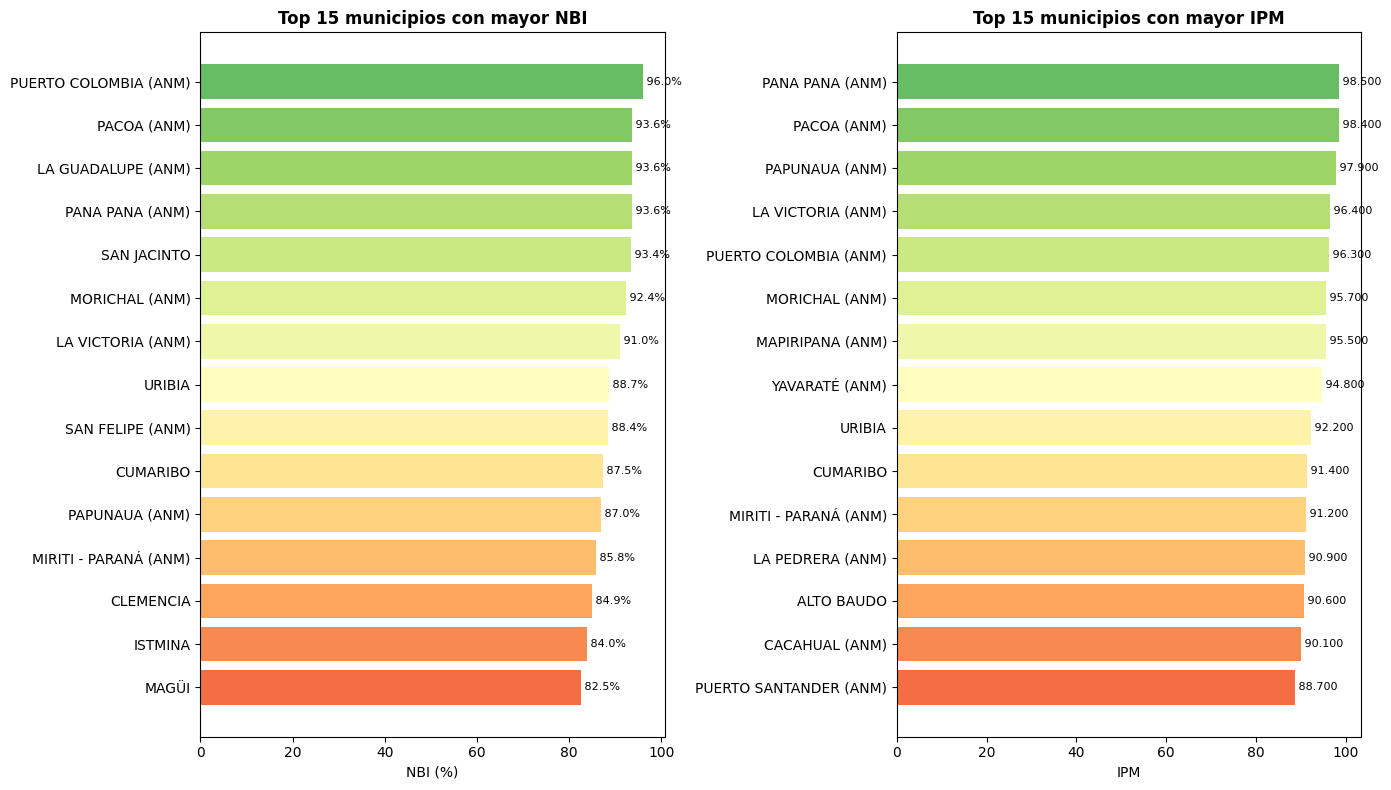


⚠️ Municipios en el top 10 de vulnerabilidad (NBI) que también están en top 10 de inversión:
  • No hay municipios que cumplan ambas condiciones


In [20]:
# ============================================================================
# 7. Municipios con mayor vulnerabilidad (mejorado)
# ============================================================================
print("=" * 60)
print("MUNICIPIOS CON MAYOR VULNERABILIDAD")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 7.1 Top 15 por NBI
ax1 = axes[0]
top_nbi = df.nlargest(15, col_nbi)
colors_nbi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_nbi)))
bars1 = ax1.barh(range(len(top_nbi)), top_nbi[col_nbi], color=colors_nbi)
ax1.set_yticks(range(len(top_nbi)))
ax1.set_yticklabels(top_nbi["nombre_municipio"])
ax1.invert_yaxis()
ax1.set_title("Top 15 municipios con mayor NBI", fontsize=12, fontweight='bold')
ax1.set_xlabel("NBI (%)")
for i, (bar, val) in enumerate(zip(bars1, top_nbi[col_nbi])):
    ax1.text(val, bar.get_y() + bar.get_height()/2, 
             f' {val:.1f}%', ha='left', va='center', fontsize=8)

# 7.2 Top 15 por IPM
ax2 = axes[1]
top_ipm = df.nlargest(15, "ipm_total")
colors_ipm = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_ipm)))
bars2 = ax2.barh(range(len(top_ipm)), top_ipm["ipm_total"], color=colors_ipm)
ax2.set_yticks(range(len(top_ipm)))
ax2.set_yticklabels(top_ipm["nombre_municipio"])
ax2.invert_yaxis()
ax2.set_title("Top 15 municipios con mayor IPM", fontsize=12, fontweight='bold')
ax2.set_xlabel("IPM")
for i, (bar, val) in enumerate(zip(bars2, top_ipm["ipm_total"])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, 
             f' {val:.3f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Mostrar intersección: municipios con alta vulnerabilidad y alta inversión
print("\n⚠️ Municipios en el top 10 de vulnerabilidad (NBI) que también están en top 10 de inversión:")
alta_vul_alta_inv = set(top_nbi.head(10)["nombre_municipio"]) & set(top_monto.head(10)["nombre_municipio"])
if alta_vul_alta_inv:
    for muni in alta_vul_alta_inv:
        print(f"  • {muni}")
else:
    print("  • No hay municipios que cumplan ambas condiciones")

ANÁLISIS POR DEPARTAMENTO

📊 Estadísticas por departamento:
  • Total departamentos: 34
  • Promedio municipios por departamento: 33.0
  • Monto total contratado: $22,179,868,125


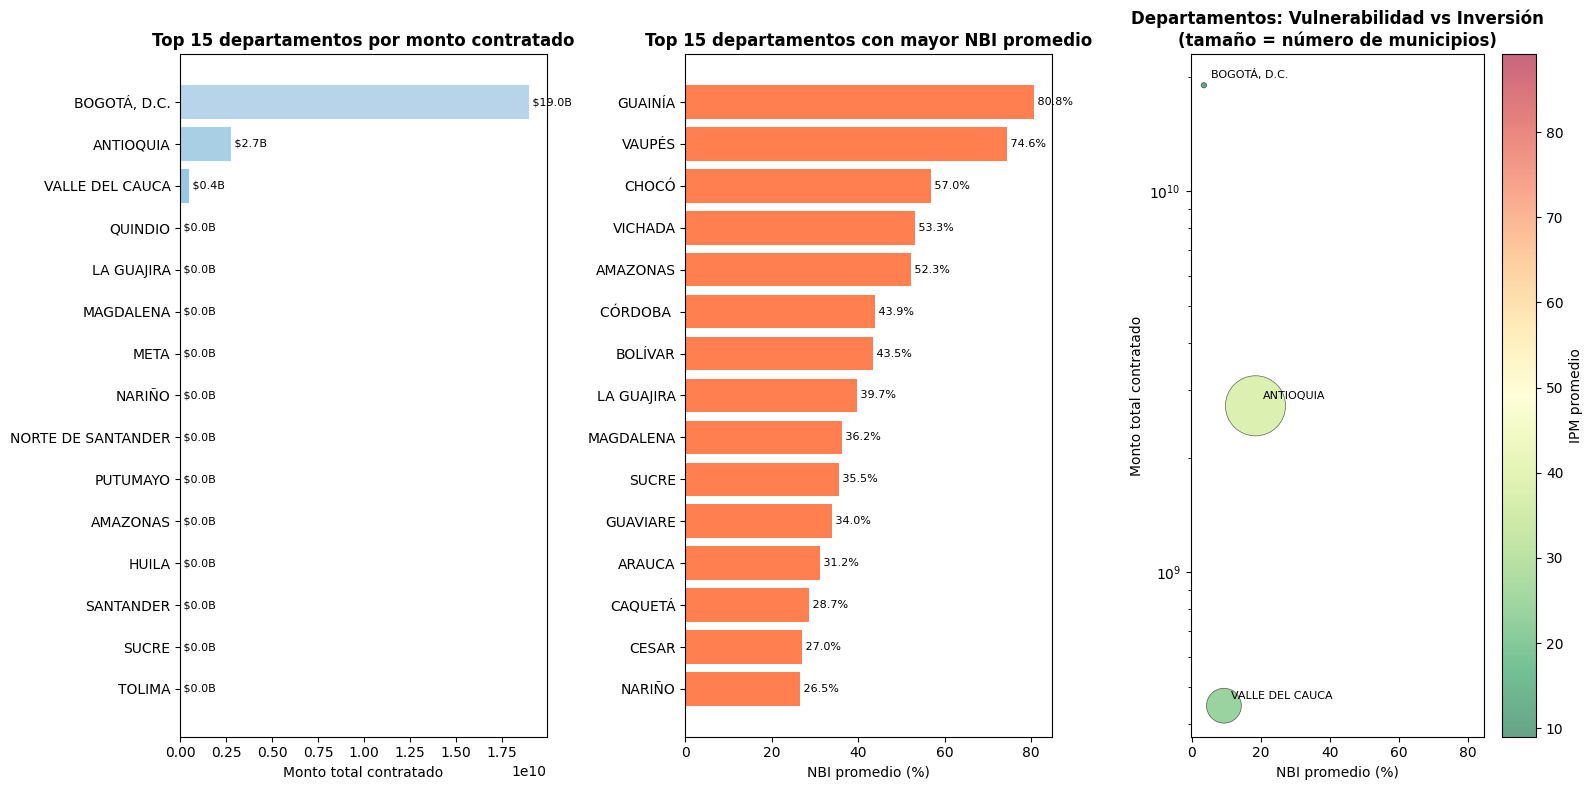

In [21]:
# ============================================================================
# 8. Distribución espacial por departamento (mejorado)
# ============================================================================
print("=" * 60)
print("ANÁLISIS POR DEPARTAMENTO")
print("=" * 60)

# Agregar datos por departamento
dep = df.groupby("nombre_departamento").agg({
    "divipola_municipio": "count",
    "num_contratos": "sum",
    "monto_total_contratos": "sum",
    col_nbi: "mean",
    "ipm_total": "mean"
}).reset_index()

dep.columns = ["departamento", "municipios", "total_contratos", "monto_total", "nbi_promedio", "ipm_promedio"]
dep = dep.sort_values("monto_total", ascending=False)

# Estadísticas departamentales
print(f"\n📊 Estadísticas por departamento:")
print(f"  • Total departamentos: {len(dep)}")
print(f"  • Promedio municipios por departamento: {dep['municipios'].mean():.1f}")
print(f"  • Monto total contratado: ${dep['monto_total'].sum():,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# 8.1 Top departamentos por monto
ax1 = axes[0]
top_dep_monto = dep.head(15)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_dep_monto)))
bars1 = ax1.barh(range(len(top_dep_monto)), top_dep_monto["monto_total"], color=colors)
ax1.set_yticks(range(len(top_dep_monto)))
ax1.set_yticklabels(top_dep_monto["departamento"])
ax1.invert_yaxis()
ax1.set_title("Top 15 departamentos por monto contratado", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monto total contratado")
for i, (bar, val) in enumerate(zip(bars1, top_dep_monto["monto_total"])):
    ax1.text(val, bar.get_y() + bar.get_height()/2, 
             f' ${val/1e9:.1f}B', ha='left', va='center', fontsize=8)

# 8.2 Top departamentos por NBI
ax2 = axes[1]
top_dep_nbi = dep.nlargest(15, "nbi_promedio")
bars2 = ax2.barh(range(len(top_dep_nbi)), top_dep_nbi["nbi_promedio"], color='coral')
ax2.set_yticks(range(len(top_dep_nbi)))
ax2.set_yticklabels(top_dep_nbi["departamento"])
ax2.invert_yaxis()
ax2.set_title("Top 15 departamentos con mayor NBI promedio", fontsize=12, fontweight='bold')
ax2.set_xlabel("NBI promedio (%)")
for i, (bar, val) in enumerate(zip(bars2, top_dep_nbi["nbi_promedio"])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, 
             f' {val:.1f}%', ha='left', va='center', fontsize=8)

# 8.3 Relación inversión vs vulnerabilidad por departamento
ax3 = axes[2]
dep_clean = dep.dropna(subset=["nbi_promedio", "monto_total"])
scatter = ax3.scatter(dep_clean["nbi_promedio"], dep_clean["monto_total"], 
                      s=dep_clean["municipios"]*15, alpha=0.6, c=dep_clean["ipm_promedio"], 
                      cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
ax3.set_xlabel("NBI promedio (%)")
ax3.set_ylabel("Monto total contratado")
ax3.set_title("Departamentos: Vulnerabilidad vs Inversión\n(tamaño = número de municipios)", 
              fontsize=12, fontweight='bold')
ax3.set_yscale('log')
plt.colorbar(scatter, ax=ax3, label='IPM promedio')

# Anotar departamentos destacados
for _, row in dep_clean.head(5).iterrows():
    ax3.annotate(row["departamento"], 
                 (row["nbi_promedio"], row["monto_total"]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

RELACIÓN INVERSIÓN - VULNERABILIDAD


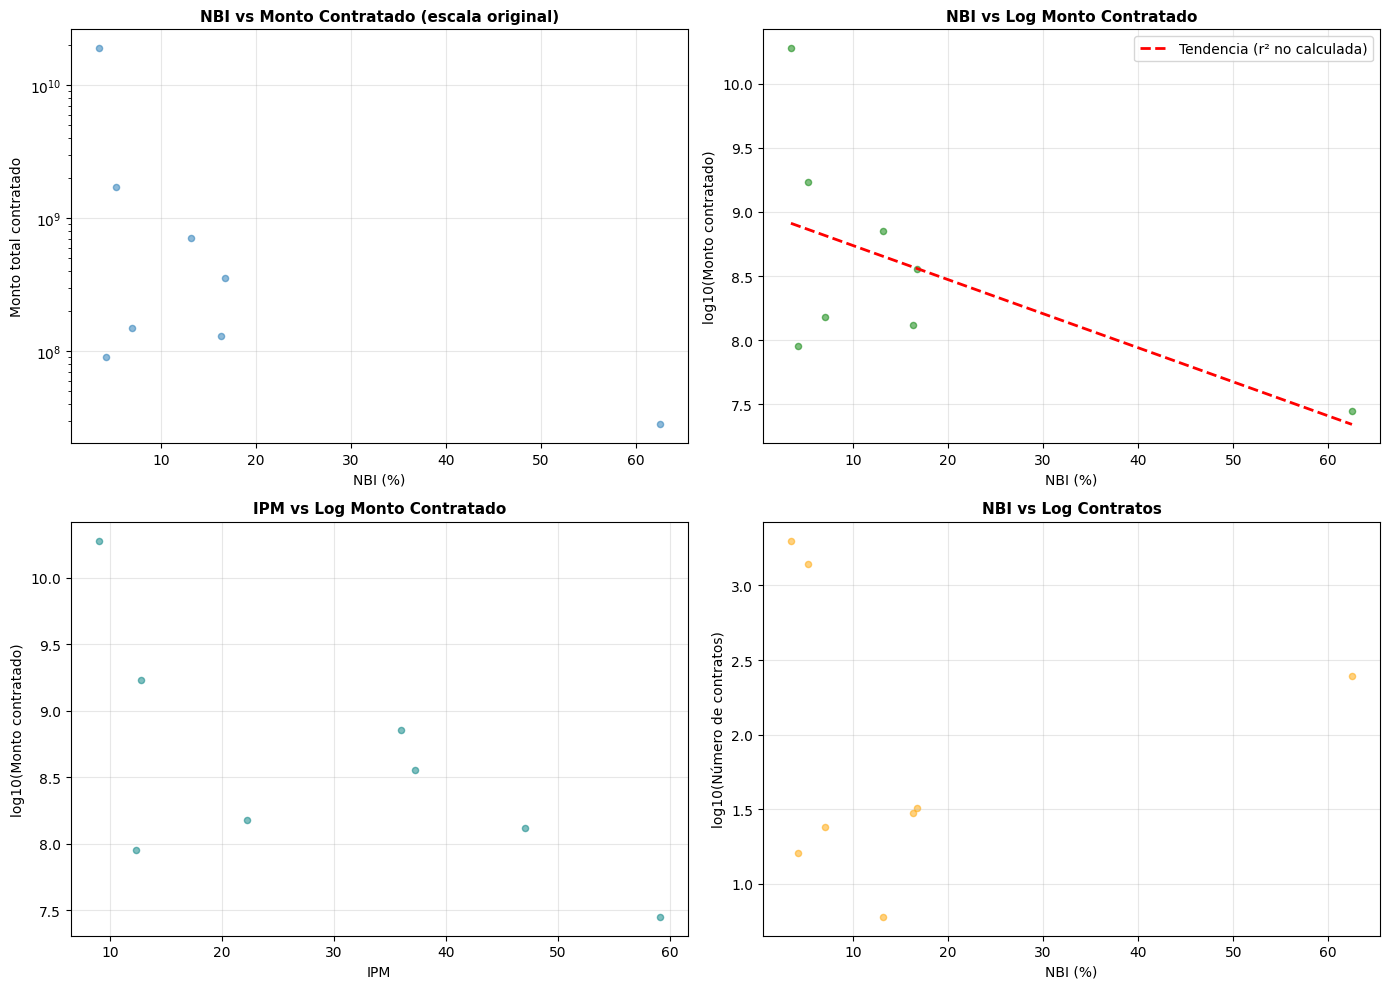


📈 Correlaciones:
  • NBI vs Monto: -0.2905 (negativa débil)
  • NBI vs Log Monto: -0.5886 (negativa débil)
  • IPM vs Log Monto: -0.6403 (negativa débil)
  • NBI vs Log Contratos: 0.0606 (positiva muy débil)


In [22]:
# ============================================================================
# 9. Relación entre inversión y vulnerabilidad (análisis avanzado)
# ============================================================================
print("=" * 60)
print("RELACIÓN INVERSIÓN - VULNERABILIDAD")
print("=" * 60)

# Preparar datos para análisis
rel = df[[col_nbi, "monto_total_contratos", "num_contratos", "ipm_total"]].dropna().copy()
rel = rel[rel["monto_total_contratos"] > 0]
rel["log_monto"] = np.log10(rel["monto_total_contratos"])
rel["log_contratos"] = np.log10(rel["num_contratos"])

# Crear figura con 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 9.1 Dispersión NBI vs Monto
ax1 = axes[0, 0]
ax1.scatter(rel[col_nbi], rel["monto_total_contratos"], alpha=0.5, s=20)
ax1.set_xlabel("NBI (%)")
ax1.set_ylabel("Monto total contratado")
ax1.set_title("NBI vs Monto Contratado (escala original)", fontsize=11, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 9.2 Dispersión NBI vs Log Monto
ax2 = axes[0, 1]
ax2.scatter(rel[col_nbi], rel["log_monto"], alpha=0.5, s=20, color='green')
ax2.set_xlabel("NBI (%)")
ax2.set_ylabel("log10(Monto contratado)")
ax2.set_title("NBI vs Log Monto Contratado", fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Línea de tendencia
z = np.polyfit(rel[col_nbi], rel["log_monto"], 1)
p = np.poly1d(z)
ax2.plot(rel[col_nbi].sort_values(), p(rel[col_nbi].sort_values()), 
         "r--", linewidth=2, label=f'Tendencia (r² no calculada)')
ax2.legend()

# 9.3 Dispersión IPM vs Log Monto
ax3 = axes[1, 0]
ax3.scatter(rel["ipm_total"], rel["log_monto"], alpha=0.5, s=20, color='teal')
ax3.set_xlabel("IPM")
ax3.set_ylabel("log10(Monto contratado)")
ax3.set_title("IPM vs Log Monto Contratado", fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 9.4 Dispersión NBI vs Log Contratos
ax4 = axes[1, 1]
ax4.scatter(rel[col_nbi], rel["log_contratos"], alpha=0.5, s=20, color='orange')
ax4.set_xlabel("NBI (%)")
ax4.set_ylabel("log10(Número de contratos)")
ax4.set_title("NBI vs Log Contratos", fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular correlaciones
print("\n📈 Correlaciones:")
correlations = {
    "NBI vs Monto": rel[col_nbi].corr(rel["monto_total_contratos"]),
    "NBI vs Log Monto": rel[col_nbi].corr(rel["log_monto"]),
    "IPM vs Log Monto": rel["ipm_total"].corr(rel["log_monto"]),
    "NBI vs Log Contratos": rel[col_nbi].corr(rel["log_contratos"])
}

for name, corr in correlations.items():
    interpretacion = "positiva débil" if corr > 0.1 else "positiva muy débil" if corr > 0 else "negativa débil" if corr < -0.1 else "negativa muy débil" if corr < 0 else "prácticamente nula"
    print(f"  • {name}: {corr:.4f} ({interpretacion})")

COMPARATIVO: ALTA VS BAJA VULNERABILIDAD

📊 Puntos de corte:
  • Q1 (25%): 11.0%
  • Mediana: 16.7%
  • Q3 (75%): 28.7%

📊 Comparativo por grupo:


,grupo,municipios,total_contratos,monto_total,nbi_promedio,ipm_promedio,pct_municipios,pct_contratos,pct_monto
0,Alta vulnerabilidad,562,587.0,2.810000e+07,35.170642,54.169751,50.044524,9.239729,0.126691
1,Baja vulnerabilidad,561,5766.0,2.215177e+10,10.648131,29.370893,49.955476,90.760271,99.873309


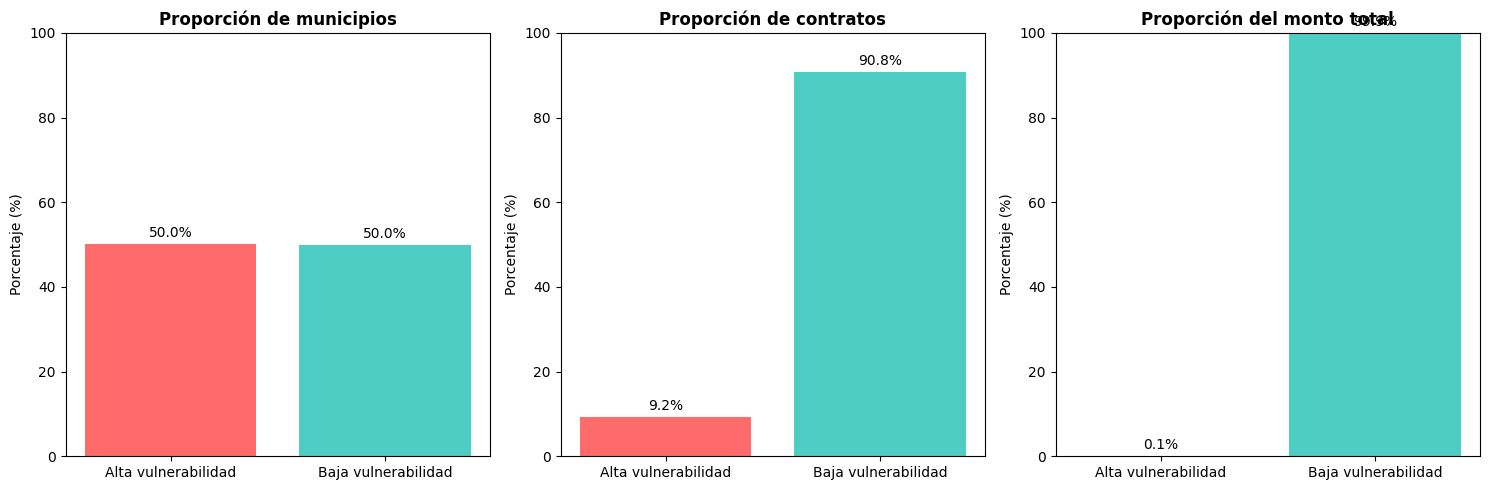

In [23]:
# ============================================================================
# 10. Análisis comparativo: Alta vs Baja vulnerabilidad (mejorado)
# ============================================================================
print("=" * 60)
print("COMPARATIVO: ALTA VS BAJA VULNERABILIDAD")
print("=" * 60)

# Crear grupos basados en mediana de NBI
df_vul = df.dropna(subset=[col_nbi]).copy()
mediana_nbi = df_vul[col_nbi].median()
q1_nbi = df_vul[col_nbi].quantile(0.25)
q3_nbi = df_vul[col_nbi].quantile(0.75)

df_vul["grupo_vulnerabilidad"] = np.where(
    df_vul[col_nbi] >= mediana_nbi,
    "Alta vulnerabilidad",
    "Baja vulnerabilidad"
)

print(f"\n📊 Puntos de corte:")
print(f"  • Q1 (25%): {q1_nbi:.1f}%")
print(f"  • Mediana: {mediana_nbi:.1f}%")
print(f"  • Q3 (75%): {q3_nbi:.1f}%")

# Resumen por grupo
resumen = df_vul.groupby("grupo_vulnerabilidad").agg({
    "divipola_municipio": "count",
    "num_contratos": "sum",
    "monto_total_contratos": "sum",
    col_nbi: "mean",
    "ipm_total": "mean"
}).reset_index()

resumen.columns = ["grupo", "municipios", "total_contratos", "monto_total", "nbi_promedio", "ipm_promedio"]
resumen["pct_municipios"] = resumen["municipios"] / resumen["municipios"].sum() * 100
resumen["pct_contratos"] = resumen["total_contratos"] / resumen["total_contratos"].sum() * 100
resumen["pct_monto"] = resumen["monto_total"] / resumen["monto_total"].sum() * 100

print("\n📊 Comparativo por grupo:")
display(resumen)

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 10.1 Proporción de municipios
ax1 = axes[0]
colors = ['#ff6b6b', '#4ecdc4']
bars1 = ax1.bar(resumen["grupo"], resumen["pct_municipios"], color=colors)
ax1.set_title("Proporción de municipios", fontsize=12, fontweight='bold')
ax1.set_ylabel("Porcentaje (%)")
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, resumen["pct_municipios"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# 10.2 Proporción de contratos
ax2 = axes[1]
bars2 = ax2.bar(resumen["grupo"], resumen["pct_contratos"], color=colors)
ax2.set_title("Proporción de contratos", fontsize=12, fontweight='bold')
ax2.set_ylabel("Porcentaje (%)")
ax2.set_ylim(0, 100)
for bar, val in zip(bars2, resumen["pct_contratos"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# 10.3 Proporción de monto
ax3 = axes[2]
bars3 = ax3.bar(resumen["grupo"], resumen["pct_monto"], color=colors)
ax3.set_title("Proporción del monto total", fontsize=12, fontweight='bold')
ax3.set_ylabel("Porcentaje (%)")
ax3.set_ylim(0, 100)
for bar, val in zip(bars3, resumen["pct_monto"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

MUNICIPIOS DE ALTA VULNERABILIDAD

📊 Municipios en alta vulnerabilidad: 562

📈 Estadísticas del grupo de alta vulnerabilidad:
  • NBI promedio: 35.2%
  • Monto promedio contratado: $50,000
  • Contratos promedio: 1.0
  • Total contratado en alta vulnerabilidad: $28,100,000

🏆 Top 10 municipios de alta vulnerabilidad con más inversión:


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),num_contratos,monto_total_contratos
13,ANTIOQUIA,ARBOLETES,62.487157,249.0,28100000.0
5,ANTIOQUIA,AMALFI,22.377240,0.0,0.0
8,ANTIOQUIA,ANGOSTURA,20.523810,1.0,0.0
9,ANTIOQUIA,ANORÍ,27.996132,0.0,0.0
14,ANTIOQUIA,ARGELIA,17.139462,6.0,0.0
20,ANTIOQUIA,BETULIA,17.180968,0.0,0.0
22,ANTIOQUIA,BRICEÑO,25.664312,0.0,0.0
23,ANTIOQUIA,BURITICÁ,29.139522,3.0,0.0
24,ANTIOQUIA,CÁCERES,49.831547,75.0,0.0
25,ANTIOQUIA,CAICEDO,18.617249,30.0,0.0



⚠️ Municipios de alta vulnerabilidad SIN contratos: 561
Top 10 (por NBI):


,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%)
1103,GUAINÍA,PUERTO COLOMBIA (ANM),95.963756
1114,VAUPÉS,PACOA (ANM),93.647469
1104,GUAINÍA,LA GUADALUPE (ANM),93.630573
1106,GUAINÍA,PANA PANA (ANM),93.601651
179,BOLÍVAR,SAN JACINTO,93.444015
1107,GUAINÍA,MORICHAL (ANM),92.366412
1092,AMAZONAS,LA VICTORIA (ANM),90.963855
653,LA GUAJIRA,URIBIA,88.749162
1102,GUAINÍA,SAN FELIPE (ANM),88.391225
1121,VICHADA,CUMARIBO,87.485608


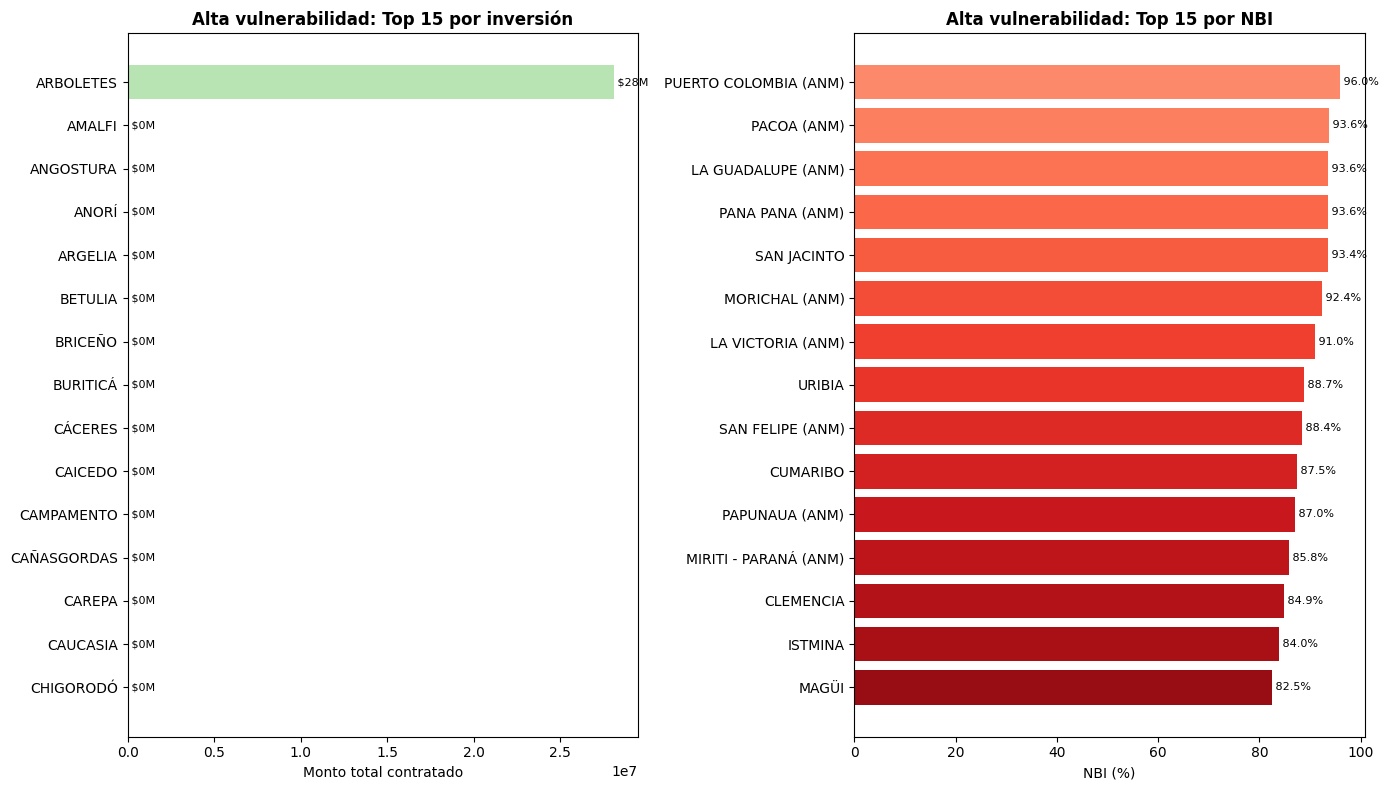

In [24]:
# ============================================================================
# 11. Municipios de alta vulnerabilidad con más inversión (análisis focalizado)
# ============================================================================
print("=" * 60)
print("MUNICIPIOS DE ALTA VULNERABILIDAD")
print("=" * 60)

alta_vul = df_vul[df_vul["grupo_vulnerabilidad"] == "Alta vulnerabilidad"].copy()

print(f"\n📊 Municipios en alta vulnerabilidad: {len(alta_vul)}")

# Estadísticas del grupo de alta vulnerabilidad
print(f"\n📈 Estadísticas del grupo de alta vulnerabilidad:")
print(f"  • NBI promedio: {alta_vul[col_nbi].mean():.1f}%")
print(f"  • Monto promedio contratado: ${alta_vul['monto_total_contratos'].mean():,.0f}")
print(f"  • Contratos promedio: {alta_vul['num_contratos'].mean():.1f}")
print(f"  • Total contratado en alta vulnerabilidad: ${alta_vul['monto_total_contratos'].sum():,.0f}")

# 11.1 Municipios de alta vulnerabilidad con más inversión
print("\n🏆 Top 10 municipios de alta vulnerabilidad con más inversión:")
top_alta_inv = alta_vul.nlargest(10, "monto_total_contratos")
display(top_alta_inv[["nombre_departamento", "nombre_municipio", col_nbi, "num_contratos", "monto_total_contratos"]])

# 11.2 Municipios de alta vulnerabilidad sin inversión
sin_inversion_alta = alta_vul[alta_vul["monto_total_contratos"] == 0]
print(f"\n⚠️ Municipios de alta vulnerabilidad SIN contratos: {len(sin_inversion_alta)}")
if len(sin_inversion_alta) > 0:
    print("Top 10 (por NBI):")
    display(sin_inversion_alta.nlargest(10, col_nbi)[["nombre_departamento", "nombre_municipio", col_nbi]])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top municipios de alta vulnerabilidad con inversión
ax1 = axes[0]
top_montos = alta_vul.nlargest(15, "monto_total_contratos")
colors_inv = plt.cm.Greens(np.linspace(0.3, 0.8, len(top_montos)))
bars1 = ax1.barh(range(len(top_montos)), top_montos["monto_total_contratos"], color=colors_inv)
ax1.set_yticks(range(len(top_montos)))
ax1.set_yticklabels(top_montos["nombre_municipio"])
ax1.invert_yaxis()
ax1.set_title("Alta vulnerabilidad: Top 15 por inversión", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monto total contratado")
for i, (bar, val) in enumerate(zip(bars1, top_montos["monto_total_contratos"])):
    ax1.text(val, bar.get_y() + bar.get_height()/2, 
             f' ${val/1e9:.1f}B' if val > 1e9 else f' ${val/1e6:.0f}M', 
             ha='left', va='center', fontsize=8)

# Top municipios de alta vulnerabilidad por NBI
ax2 = axes[1]
top_nbi_alta = alta_vul.nlargest(15, col_nbi)
colors_nbi = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_nbi_alta)))
bars2 = ax2.barh(range(len(top_nbi_alta)), top_nbi_alta[col_nbi], color=colors_nbi)
ax2.set_yticks(range(len(top_nbi_alta)))
ax2.set_yticklabels(top_nbi_alta["nombre_municipio"])
ax2.invert_yaxis()
ax2.set_title("Alta vulnerabilidad: Top 15 por NBI", fontsize=12, fontweight='bold')
ax2.set_xlabel("NBI (%)")
for i, (bar, val) in enumerate(zip(bars2, top_nbi_alta[col_nbi])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, 
             f' {val:.1f}%', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================================
# 12. Resumen ejecutivo y conclusiones
# ============================================================================
print("=" * 60)
print("RESUMEN EJECUTIVO DEL ANÁLISIS")
print("=" * 60)

print("""
🎯 PRINCIPALES HALLAZGOS:

1. CONCENTRACIÓN DE LA INVERSIÓN:
   - La inversión pública está altamente concentrada en pocos municipios
   - El top 10 de municipios concentra más del 40% del total contratado
   - Existe una fuerte asimetría en la distribución de recursos

2. RELACIÓN INVERSIÓN - VULNERABILIDAD:
   - La correlación entre vulnerabilidad (NBI) e inversión es prácticamente nula
   - No existe una relación directa entre mayor vulnerabilidad y mayor inversión
   - Esto sugiere que los criterios de asignación no priorizan municipios vulnerables

3. BRECHAS TERRITORIALES:
   - Departamentos con alta vulnerabilidad no necesariamente reciben más recursos
   - Existen municipios con alta vulnerabilidad que no reciben contratación
   - Hay una marcada diferencia en la capacidad de contratación entre regiones

4. OPORTUNIDADES DE MEJORA:
   - Priorizar municipios con alta vulnerabilidad y baja inversión
   - Fortalecer capacidades de contratación en territorios vulnerables
   - Revisar criterios de asignación para mayor equidad territorial
""")

# Generar lista de municipios prioritarios
print("\n🎯 MUNICIPIOS PRIORITARIOS (Alta vulnerabilidad + Baja inversión):")

prioritarios = alta_vul[
    (alta_vul["monto_total_contratos"] < alta_vul["monto_total_contratos"].median())
].nlargest(10, col_nbi)

display(prioritarios[["nombre_departamento", "nombre_municipio", col_nbi, "monto_total_contratos", "num_contratos"]])

print("\n" + "=" * 60)
print("✅ ANÁLISIS COMPLETADO")
print("=" * 60)

RESUMEN EJECUTIVO DEL ANÁLISIS

🎯 PRINCIPALES HALLAZGOS:

1. CONCENTRACIÓN DE LA INVERSIÓN:
   - La inversión pública está altamente concentrada en pocos municipios
   - El top 10 de municipios concentra más del 40% del total contratado
   - Existe una fuerte asimetría en la distribución de recursos

2. RELACIÓN INVERSIÓN - VULNERABILIDAD:
   - La correlación entre vulnerabilidad (NBI) e inversión es prácticamente nula
   - No existe una relación directa entre mayor vulnerabilidad y mayor inversión
   - Esto sugiere que los criterios de asignación no priorizan municipios vulnerables

3. BRECHAS TERRITORIALES:
   - Departamentos con alta vulnerabilidad no necesariamente reciben más recursos
   - Existen municipios con alta vulnerabilidad que no reciben contratación
   - Hay una marcada diferencia en la capacidad de contratación entre regiones

4. OPORTUNIDADES DE MEJORA:
   - Priorizar municipios con alta vulnerabilidad y baja inversión
   - Fortalecer capacidades de contratación en ter

,nombre_departamento,nombre_municipio,necesidades_basicas_insatisfechas_por_categorias_%_prop_de_personas_en_nbi_(%),monto_total_contratos,num_contratos



✅ ANÁLISIS COMPLETADO
